# Module 03 — Data Wrangling with Pandas

*Anatomy of a pandemic: four and a half years of COVID-19, one country at a time.*

Starting in January 2020, a research group at the University of Oxford called **Our World in Data** began collecting every country's official COVID-19 reports — cases, deaths, hospital numbers, tests, vaccinations — into a single table, updated daily, for the whole world. That table powered most of the pandemic dashboards you saw on the news, and it's what we'll work with: **396,995 rows** covering 237 countries from January 2020 to August 2024.

It is also gloriously messy, the way real surveillance data always is: countries that stopped reporting mid-pandemic, columns only wealthy countries ever filled in, case counts delivered in weekly batches, and even a couple of duplicated rows. Cleaning, reshaping, and combining tables like this is called **data wrangling**, and it's most of what working scientists actually do with their time. This module teaches the four core moves: **filter, reshape, merge, aggregate**.

Run each cell in order; predict before you run. As always, every non-obvious line has a `#` comment explaining it.

In [1]:
import numpy as np                # arrays (Module 01)
import pandas as pd               # tables (Module 02) -- now at real-world scale
import matplotlib.pyplot as plt   # drawing plots
import seaborn as sns             # nicer-looking plots

sns.set_theme(style="whitegrid", palette="colorblind")

# Same idea as Modules 01-02: one fixed color per group, reused in every plot.
# These are the four countries we'll follow through the pandemic.
palette = sns.color_palette("colorblind")
COUNTRY_COLORS = {"United States": palette[0],   # blue
                  "India": palette[1],           # orange
                  "Germany": palette[2],         # green
                  "South Africa": palette[3]}    # reddish

## 1. Load the data

Same recipe as always — `load_dataset(...)` then `.to_pandas()` — but this dataset is about **a thousand times bigger** than the penguins, so the first download takes a few seconds (after that it's cached on your laptop).

In [2]:
from datasets import load_dataset   # the HuggingFace downloader (same as before)

# Download the Our World in Data COVID table and convert it to a DataFrame.
covid_raw = load_dataset("EPI-Eval/owid-covid", split="train").to_pandas()

print("shape:", covid_raw.shape)   # (rows, columns) -- our biggest table yet
covid_raw.head()

shape: (396995, 15)


,date,location_id,location_level,location_name,new_cases,new_deaths,icu_patients,hosp_patients,weekly_icu_admissions,weekly_hosp_admissions,new_tests,positive_rate,people_vaccinated,people_fully_vaccinated,total_boosters
0,2020-01-01 00:00:00+00:00,AR,national,Argentina,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
1,2020-01-01 00:00:00+00:00,MX,national,Mexico,NaN,NaN,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN,NaN
2,2020-01-02 00:00:00+00:00,AR,national,Argentina,NaN,NaN,NaN,NaN,NaN,NaN,95.0,NaN,NaN,NaN,NaN
3,2020-01-02 00:00:00+00:00,MX,national,Mexico,NaN,NaN,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN,NaN
4,2020-01-03 00:00:00+00:00,AR,national,Argentina,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN


Time for the **first-look ritual** from Module 02 — `head()`, `shape`, `info()`, `describe()` — which matters *more* on a big dataset, not less, because you can't just eyeball 400,000 rows. Two things to hunt for in `info()`: the **type** of each column, and how many **non-null** (non-missing) values it has.

In [3]:
# info() lists every column with its non-missing count and its type.
covid_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 396995 entries, 0 to 396994
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype              
---  ------                   --------------   -----              
 0   date                     396995 non-null  datetime64[us, UTC]
 1   location_id              396995 non-null  str                
 2   location_level           396995 non-null  str                
 3   location_name            396995 non-null  str                
 4   new_cases                390071 non-null  float64            
 5   new_deaths               390520 non-null  float64            
 6   icu_patients             34825 non-null   float64            
 7   hosp_patients            35442 non-null   float64            
 8   weekly_icu_admissions    10993 non-null   float64            
 9   weekly_hosp_admissions   19666 non-null   float64            
 10  new_tests                75300 non-null   float64            
 11  positive_rate           

Two discoveries hiding in that printout:

1. The `date` column's type is `datetime64` — a **date-and-time data type**, not text. New to us; section 3 is all about it.
2. Several columns (ICU patients, tests, vaccinations) have *far* fewer non-null values than the 396,995 rows — we'll deal with that in section 4.

## 2. Filter to countries (and check for duplicates)

The `location_level` column warns us that not every row is a country: some rows are **"global"** — totals for the whole world. Mixing levels is a classic wrangling trap: sum a column with the World rows included and you count every case twice (once in its country's row, once in the World row). It's like summing a gene-expression matrix with the "total counts" row left in.

In [4]:
# How many rows of each level are there?
print(covid_raw["location_level"].value_counts())

# Keep ONLY the national (country) rows.
# .copy() makes an independent table, so pandas lets us add columns to it
# later without complaining that it's just a view of covid_raw (Module 02).
covid = covid_raw[covid_raw["location_level"] == "national"].copy()
print("\ncountry rows kept:", len(covid))
print("number of countries:", covid["location_name"].nunique())   # nunique = count of distinct values

location_level
national    395311
global        1684
Name: count, dtype: int64

country rows kept: 395311
number of countries: 237


One more check that belongs in the ritual whenever a dataset was *compiled from many sources*: **duplicates**. This table should have exactly one row per country per date. `.duplicated()` checks that for us — it marks a row `True` if an identical row appeared earlier; `subset=[...]` says "compare only these columns".

In [5]:
# keep=False means: mark EVERY copy of a duplicated (country, date) pair,
# not just the second one -- so we can look at all of them.
dup_mask = covid.duplicated(subset=["location_name", "date"], keep=False)
print("rows involved in duplicate pairs:", dup_mask.sum())

# Which countries are affected? .unique() lists each distinct value once.
print("affected countries:", covid[dup_mask]["location_name"].unique())

# Look at one example pair: East Timor on 2021-02-14 appears twice.
example = covid[dup_mask & (covid["location_name"] == "East Timor")]
example[["date", "location_name", "new_cases", "new_deaths"]].head(4)

rows involved in duplicate pairs: 2816
affected countries: <ArrowStringArray>
['Faroe Islands', 'East Timor']
Length: 2, dtype: str


,date,location_name,new_cases,new_deaths
95543,2021-02-12 00:00:00+00:00,East Timor,0.0,0.0
95544,2021-02-12 00:00:00+00:00,East Timor,NaN,NaN
95782,2021-02-13 00:00:00+00:00,East Timor,0.0,0.0
95783,2021-02-13 00:00:00+00:00,East Timor,NaN,NaN


In [6]:
# Each duplicated date has one real row and one empty (all-NaN) row --
# a glitch in how these two small territories' data was compiled.
# drop_duplicates() keeps the first copy of each pair and drops the rest.
# We won't be analyzing these two territories, so either copy would be fine.
rows_before = len(covid)
covid = covid.drop_duplicates(subset=["location_name", "date"])
print("rows before:", rows_before, "-> after:", len(covid))

rows before: 395311 -> after: 393903


## 3. Dates are a real data type

So far our columns held numbers or text. `date` is a third kind: **`datetime64`**, pandas' data type for points in time. It's not text that looks like a date — pandas can do *calendar math* with it: extract the year, ask which weekday a date fell on, keep only rows between two dates.

One wrinkle first: `info()` showed the type as `datetime64[us, UTC]`. The `UTC` part means the dates are **timezone-aware** — pinned to Coordinated Universal Time, the reference clock at 0° longitude that the world's timezones are defined against. That's vital when timestamps must line up across the globe (lab instruments do this too), but our rows are just *calendar days* of national reports, and dragging a timezone along makes comparisons noisier to write. So we drop it and keep plain dates.

In [7]:
# .dt is the gateway to everything date-related about a column.
# .dt.tz_localize(None) means 'strip the timezone label, keep the date'.
covid["date"] = covid["date"].dt.tz_localize(None)

print("first date:", covid["date"].min())
print("last date: ", covid["date"].max())

first date: 2020-01-01 00:00:00
last date:  2024-08-14 00:00:00


In [8]:
# .dt.year pulls the year out of every date at once (vectorized, Module 01).
covid["year"] = covid["date"].dt.year

# Total reported cases per year, worldwide, in millions.
# groupby: split the rows by year, sum new_cases in each group, combine.
cases_by_year = covid.groupby("year")["new_cases"].sum() / 1_000_000
# (Python lets you write 1000000 as 1_000_000 -- the underscores are just
#  for human eyes, like thousands separators.)
cases_by_year.round(1)

year
2020     80.3
2021    200.2
2022    423.9
2023     69.2
2024      2.1
Name: new_cases, dtype: float64

Read that like an epidemiologist: 2020's lockdowns held reported cases to ~80 million, 2021 (Alpha, then Delta) more than doubled that, and 2022 — the **Omicron** year — was the biggest of all at ~424 million. The 2023–24 numbers collapse partly because the pandemic waned, and partly because countries simply *stopped counting* — a reporting artifact, not just biology.

**Filtering by date** works exactly like the boolean masks of Module 02: a comparison makes a column of `True`/`False`. The only new piece is `pd.Timestamp("2021-05-01")`, which turns text into a proper date so it can be compared against a datetime column.

In [9]:
# India's catastrophic Delta wave: how many cases in May 2021 alone?
# Three conditions joined with & -- each needs its own parentheses (Module 02).
india_may = covid[(covid["location_name"] == "India")
                  & (covid["date"] >= pd.Timestamp("2021-05-01"))
                  & (covid["date"] < pd.Timestamp("2021-06-01"))]

print("days in the slice:", len(india_may))
print("reported cases in May 2021:", int(india_may["new_cases"].sum()))

days in the slice: 31
reported cases in May 2021: 10934628


Almost **11 million reported cases in one month**, in one country. Hold that number — sections 8–9 will ask whether it was really the world's worst wave.

## 4. Missing data at scale

Module 02 taught the tools (`isna`, `dropna`, `fillna`); here's the same idea on a dataset where some columns are *mostly* holes. One upgrade: with 16 columns and 393,903 rows, raw counts of missing values are hard to judge, so we ask for the **fraction** missing instead. `.isna()` gives `True`/`False`, and the *mean* of `True`/`False` values is exactly the fraction that are `True` (Module 01's counting trick).

In [10]:
# Fraction of missing values per column, worst first.
# sort_values on a Series sorts by the values themselves.
covid.isna().mean().round(3).sort_values(ascending=False)

weekly_icu_admissions      0.972
weekly_hosp_admissions     0.950
icu_patients               0.912
hosp_patients              0.910
total_boosters             0.905
people_fully_vaccinated    0.849
people_vaccinated          0.841
new_tests                  0.809
positive_rate              0.758
new_cases                  0.015
new_deaths                 0.014
date                       0.000
location_id                0.000
location_level             0.000
location_name              0.000
year                       0.000
dtype: float64

In surveillance data, `NaN` almost never means "the measurement failed" — it means **"this country never reported this number"**. ICU occupancy is 91% missing because only a few (mostly wealthy) countries published it; vaccination columns are 84–90% missing because most countries reported them rarely or not at all. Dropping every incomplete row here would delete nearly the whole world — the wrong call.

The wrangler's move instead: **choose columns to match the question**. Our questions are about cases and deaths, and `new_cases` / `new_deaths` are ~98% present. We keep the gaps in the other columns and simply don't use them.

## 5. Raw daily cases: the comb

Time to actually *look* at an epidemic. We'll follow four countries — the United States, India, Germany, and South Africa: four continents, wildly different population sizes, which is exactly what will make the per-person comparison interesting later.

First, a new filtering tool: `.isin(...)` asks, for every row, "is this value in my list?" — a mask, like `==` but for several allowed values at once.

In [11]:
FOCUS = ["United States", "India", "Germany", "South Africa"]

# Analysis window: March 2020 (pandemic declared) to March 2023.
# We stop there because the US quit reporting case counts in May 2023.
START = pd.Timestamp("2020-03-01")
END = pd.Timestamp("2023-03-01")

# .isin(FOCUS) -> True for rows whose country is one of our four.
four = covid[covid["location_name"].isin(FOCUS)
             & (covid["date"] >= START)
             & (covid["date"] <= END)].copy()

# One row per country per day -> each country should have the same count.
four["location_name"].value_counts()

location_name
Germany          1096
India            1096
United States    1096
South Africa     1096
Name: count, dtype: int64

Before plotting, do what a careful scientist does: **read a few raw numbers**. Here are two weeks of the United States column in January 2021, with each date's weekday next to it (`.dt.day_name()` — another `.dt` trick).

In [12]:
# Just the US rows from our four-country table.
us = four[four["location_name"] == "United States"].copy()

# .dt.day_name() converts each date to 'Monday', 'Tuesday', ...
us["weekday"] = us["date"].dt.day_name()

# Two mid-pandemic weeks, January 2021:
jan_window = us[(us["date"] >= pd.Timestamp("2021-01-10"))
                & (us["date"] <= pd.Timestamp("2021-01-24"))]
jan_window[["date", "weekday", "new_cases"]]

,date,weekday,new_cases
87746,2021-01-10,Sunday,1667151.0
87982,2021-01-11,Monday,0.0
88218,2021-01-12,Tuesday,0.0
88454,2021-01-13,Wednesday,0.0
88690,2021-01-14,Thursday,0.0
88926,2021-01-15,Friday,0.0
89162,2021-01-16,Saturday,0.0
89398,2021-01-17,Sunday,1589955.0
89634,2021-01-18,Monday,0.0
89870,2021-01-19,Tuesday,0.0


Look at the pattern: **zeros all week, then ~1.6 million cases every Sunday.** The virus did not take six days off — in this dataset, countries report cases in **weekly batches**, and the compilers put each week's total on the Sunday. The pattern is bureaucratic, not biological (in fact *every* nonzero value in this dataset lands on a Sunday).

Plot the raw column and you get not an epidemic curve but a comb:

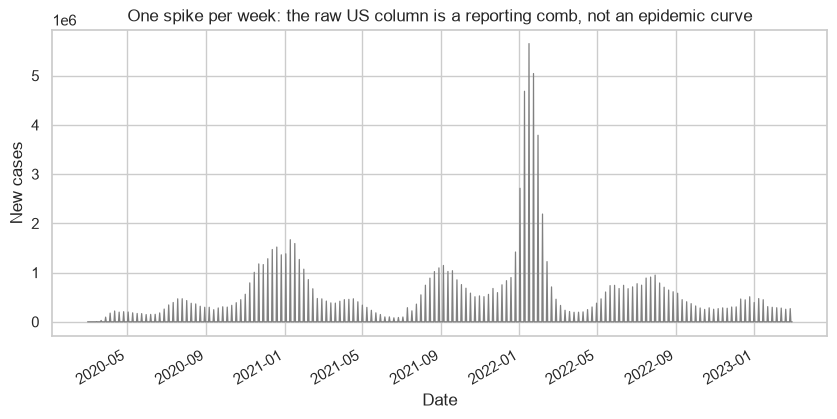

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(us["date"], us["new_cases"],
        color="gray", linewidth=0.9)
ax.set_xlabel("Date")
ax.set_ylabel("New cases")
ax.set_title("One spike per week: the raw US column is a reporting comb, not an epidemic curve")
fig.autofmt_xdate()   # tilt the date labels so they don't overlap
plt.show()

## 6. The 7-day rolling average

The fix every dashboard used is a **rolling average** (also called a *moving average*): for each day, replace the value with the average of the last 7 days. It's a **sliding window** — the same idea as plotting GC content along a chromosome in 1,000-bp windows: you give up single-position detail and in exchange the real shape becomes visible.

In pandas that's `.rolling(7).mean()`: "form a window of the 7 most recent rows, then take its mean" — and averaging over exactly 7 days works perfectly here, because every window catches exactly one Sunday batch plus six zeros, spreading each week's total back out over its days.

One catch: rolling assumes the rows are **in time order**, so we sort first. And the first 6 rows get `NaN` — the window isn't full yet, so there's honestly nothing to average.

In [14]:
# Make sure the rows run oldest -> newest before rolling.
us = us.sort_values("date").copy()

# For each row: average of that day's value and the 6 days before it.
us["cases_smoothed"] = us["new_cases"].rolling(7).mean()

# First 8 rows: watch the NaNs until the 7-day window fills up.
us[["date", "new_cases", "cases_smoothed"]].head(8)

,date,new_cases,cases_smoothed
13406,2020-03-01,33.0,NaN
13642,2020-03-02,0.0,NaN
13878,2020-03-03,0.0,NaN
14114,2020-03-04,0.0,NaN
14350,2020-03-05,0.0,NaN
14586,2020-03-06,0.0,NaN
14822,2020-03-07,0.0,4.714286
15058,2020-03-08,391.0,55.857143


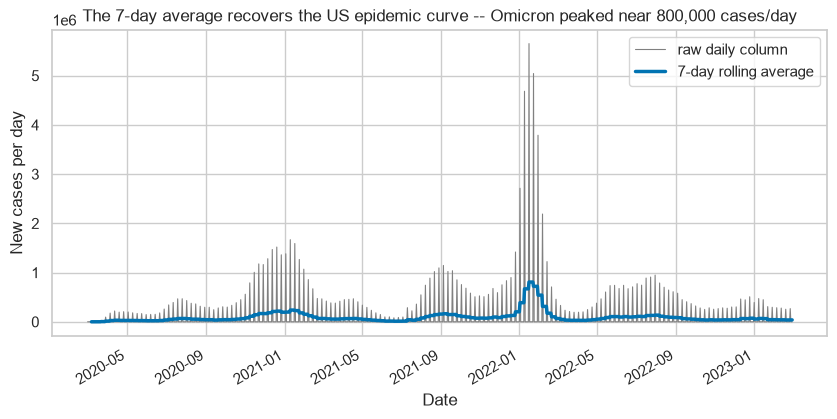

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))

# Raw comb in thin gray, smoothed curve thick and colored on top.
ax.plot(us["date"], us["new_cases"],
        color="gray", linewidth=0.8, label="raw daily column")
ax.plot(us["date"], us["cases_smoothed"],
        color=COUNTRY_COLORS["United States"], linewidth=2.5,
        label="7-day rolling average")
ax.set_xlabel("Date")
ax.set_ylabel("New cases per day")
ax.set_title("The 7-day average recovers the US epidemic curve -- Omicron peaked near 800,000 cases/day")
ax.legend()
fig.autofmt_xdate()
plt.show()

Note the units: each smoothed point is **average cases per day** over the trailing week. The Omicron peak lands at 807,276 cases per day on 2022-01-16 — about 5.7 million Americans testing positive in a single week.

## 7. Long vs wide: pivot and melt

Now smooth all four countries. Our table is in **long** format — one row per country-and-date pair, countries stacked on top of each other. The natural spreadsheet layout is **wide** — one row per date, one *column* per country. Same measurements, two shapes (the README has a picture of this).

`pivot` converts long → wide. You tell it three things: which column becomes the row labels (`index`), which column's values become the new column *names* (`columns`), and which column fills the cells (`values`). This is also why we checked duplicates in section 2: pivot needs exactly one value per (date, country) cell.

In [16]:
# Long -> wide: rows = dates, one column per country, cells = new_cases.
wide = four.pivot(index="date", columns="location_name", values="new_cases")

print("shape:", wide.shape)   # 1,096 days x 4 countries
wide.head(8)   # first row is Sunday 2020-03-01 (batch day), then the zeros

shape: (1096, 4)


location_name,Germany,India,South Africa,United States
date,,,,
2020-03-01,139.0,0.0,0.0,33.0
2020-03-02,0.0,0.0,0.0,0.0
2020-03-03,0.0,0.0,0.0,0.0
2020-03-04,0.0,0.0,0.0,0.0
2020-03-05,0.0,0.0,0.0,0.0
2020-03-06,0.0,0.0,0.0,0.0
2020-03-07,0.0,0.0,0.0,0.0
2020-03-08,905.0,32.0,2.0,391.0


The payoff of wide format: the four countries now share one set of date rows, so **a single `.rolling(7).mean()` smooths all four columns at once** — in long format we'd have to smooth each country separately (careful not to let one country's window slide into the next country's rows).

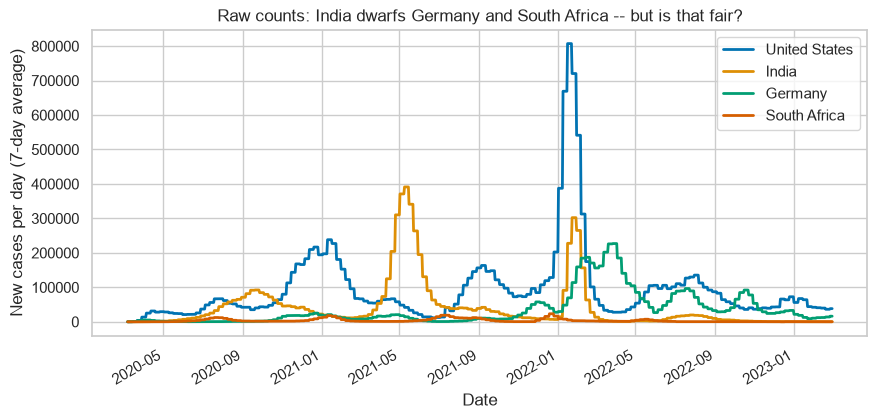

In [17]:
# One line smooths every column of the wide table simultaneously.
wide_smooth = wide.rolling(7).mean()

fig, ax = plt.subplots(figsize=(10, 4.5))

# A plain loop over our four countries, one line each, fixed colors.
for country in FOCUS:
    ax.plot(wide_smooth.index,          # the dates (pivot made them the row labels)
            wide_smooth[country],       # that country's smoothed column
            color=COUNTRY_COLORS[country], linewidth=2, label=country)

ax.set_xlabel("Date")
ax.set_ylabel("New cases per day (7-day average)")
ax.set_title("Raw counts: India dwarfs Germany and South Africa -- but is that fair?")
ax.legend()
fig.autofmt_xdate()
plt.show()

India's spring-2021 Delta wave towers over everything except US Omicron, and South Africa barely registers. Keep a biologist's suspicion, though: India has 1.4 **billion** people, South Africa 59 million. Raw counts compare countries the way raw read counts compare sequencing libraries — not at all, until you normalize.

To normalize we need each row to carry its country's population, and that's a job for *long* format. `melt` is pivot's inverse: it stacks the wide columns back into rows. One preparatory step: pivot moved the dates into the row labels (the index), and melt only looks at real columns — so `reset_index()` first, which turns the row labels back into an ordinary `date` column.

In [18]:
# Wide -> long again, now carrying the SMOOTHED values.
long_smooth = wide_smooth.reset_index().melt(
    id_vars="date",                  # id_vars: column(s) to repeat, not stack
    var_name="location_name",        # name for the new 'which column was it' column
    value_name="cases_smoothed")     # name for the new column of cell values

# 1,096 dates x 4 countries = 4,384 rows, back in one-row-per-pair shape.
print("shape:", long_smooth.shape)
long_smooth.head()

shape: (4384, 3)


,date,location_name,cases_smoothed
0,2020-03-01,Germany,NaN
1,2020-03-02,Germany,NaN
2,2020-03-03,Germany,NaN
3,2020-03-04,Germany,NaN
4,2020-03-05,Germany,NaN


## 8. Merge in the population table

Population isn't a column in the COVID table — it lives in a second, hand-made table in this repo, [`datasets/country_populations.csv`](../../datasets/country_populations.csv): 30 major countries with their population (UN 2021 estimates, rounded) and continent.

Combining two tables on a shared column is a **merge** (database people say *join*). Rows pair up wherever the **key** column — country name — matches, and the matched rows pick up the new columns. Two rules the README's merge diagram illustrates:

- the key must match **exactly** — "United States" pairs with "United States", never "USA";
- a row with no partner gets `NaN` in the new columns, so *always check for unmatched rows after a merge*.

In [19]:
# pd.read_csv loads a plain text file of comma-separated values into a DataFrame.
# The ../../ walks up from this module folder to the repo's datasets/ folder.
pops = pd.read_csv("../../datasets/country_populations.csv")

print("shape:", pops.shape)
pops.head()

shape: (30, 3)


,country,population,continent
0,United States,337000000,North America
1,Canada,38000000,North America
2,Mexico,127000000,North America
3,Brazil,214000000,South America
4,Argentina,45000000,South America


In [20]:
# Merge: for each row of long_smooth, find the pops row whose 'country'
# equals its 'location_name', and glue that row's columns on.
merged = pd.merge(long_smooth, pops,
                  left_on="location_name",   # key column in the LEFT table
                  right_on="country",        # key column in the RIGHT table
                  how="left")                # keep every left row, matched or not

# The post-merge safety check: did anyone fail to find a partner?
print("rows with no population match:", merged["population"].isna().sum())
merged.head(3)

rows with no population match: 0


,date,location_name,cases_smoothed,country,population,continent
0,2020-03-01,Germany,NaN,Germany,83000000,Europe
1,2020-03-02,Germany,NaN,Germany,83000000,Europe
2,2020-03-03,Germany,NaN,Germany,83000000,Europe


Zero unmatched rows — all four countries found their population. Now the normalization: **cases per million people**, computed for every row at once. (Genomics does the identical thing when it normalizes read counts to CPM — literally *counts per million*.)

In [21]:
# population / 1,000,000 = 'how many millions of people live here';
# dividing by that converts raw cases into cases per million people.
merged["cases_per_million"] = merged["cases_smoothed"] / (merged["population"] / 1_000_000)

merged[["date", "location_name", "cases_smoothed", "population", "cases_per_million"]].head(3)

,date,location_name,cases_smoothed,population,cases_per_million
0,2020-03-01,Germany,NaN,83000000,NaN
1,2020-03-02,Germany,NaN,83000000,NaN
2,2020-03-03,Germany,NaN,83000000,NaN


## 9. The per-million reveal

Same four epidemic curves, side by side: raw counts on the left, per million people on the right. Since `merged` is in long format, seaborn's `lineplot` can draw all four countries per panel with `hue` — exactly why we melted.

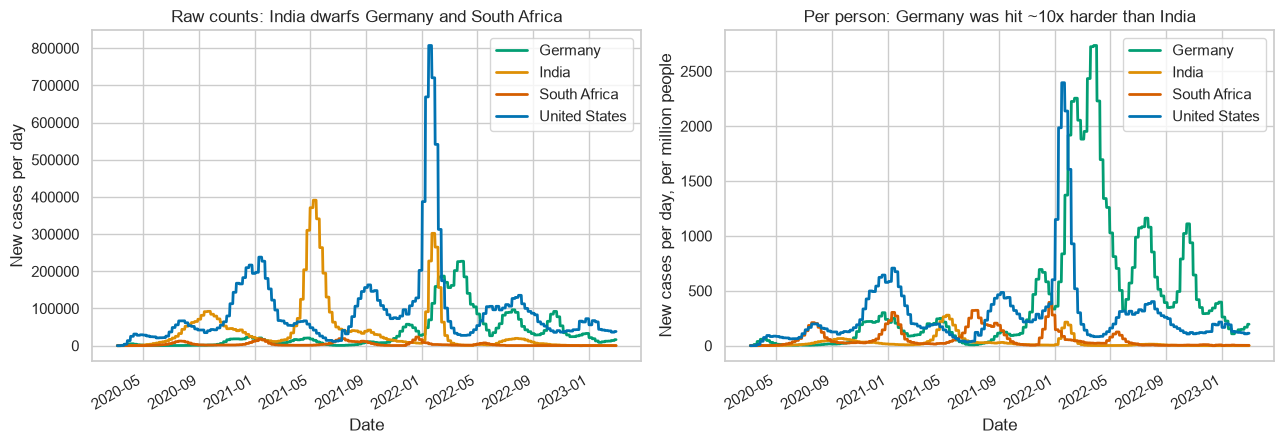

In [22]:
# One figure, two panels side by side (1 row, 2 columns of axes).
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# LEFT: raw counts (what section 7 showed).
sns.lineplot(data=merged, x="date", y="cases_smoothed",
             hue="location_name",          # one line per country...
             palette=COUNTRY_COLORS,       # ...in our fixed colors
             linewidth=2, ax=axes[0])
axes[0].set_xlabel("Date")
axes[0].set_ylabel("New cases per day")
axes[0].set_title("Raw counts: India dwarfs Germany and South Africa")
axes[0].legend(title=None)

# RIGHT: the same data divided by population.
sns.lineplot(data=merged, x="date", y="cases_per_million",
             hue="location_name", palette=COUNTRY_COLORS,
             linewidth=2, ax=axes[1])
axes[1].set_xlabel("Date")
axes[1].set_ylabel("New cases per day, per million people")
axes[1].set_title("Per person: Germany was hit ~10x harder than India")
axes[1].legend(title=None)

fig.autofmt_xdate()
plt.tight_layout()   # stop the two panels from overlapping
plt.show()

The story flips completely. Per million people, Germany's Omicron wave peaked around **2,700 daily cases per million** — roughly 1 in every 370 Germans testing positive *per day* — and the US around 2,400. India's Delta wave, the left panel's giant, peaked near **280 per million**, and South Africa's waves now clearly rival India's.

Two honest caveats, because this is real epidemiology:

- These are **reported** cases. India's testing capacity was overwhelmed during Delta; antibody surveys later suggested the true infection count was many times higher. A per-capita plot fixes the *denominator* problem, not the *detection* problem.
- Our populations are 2021 snapshots applied to all five years — fine at this resolution, sloppy for precision work.

The method is the lesson: **a raw count is meaningless until you know what to divide it by.** Same reason expression data gets normalized per million reads.

## 10. Group-by at scale: deaths by continent

The grand finale chains all four wrangling moves into one pipeline, using *every* country, not just our four:

1. **aggregate** — total deaths per country (`groupby` + `sum`, 237 rows)
2. **merge** — attach continent and population from the CSV (only 30 will match!)
3. **aggregate again** — summarize by continent

Step 2 is the README diagram's "Chad situation" for real: 207 of 237 countries aren't in our little CSV, and we'll watch them get `NaN`.

In [23]:
# Step 1: total reported deaths per country, whole pandemic.
# as_index=False keeps location_name as a normal column instead of row labels,
# which makes the next merge easier to write.
deaths_by_country = covid.groupby("location_name", as_index=False)["new_deaths"].sum()

# rename(columns={old: new}) gives the summed column a clearer name.
deaths_by_country = deaths_by_country.rename(columns={"new_deaths": "total_deaths"})

# The five countries with the most reported deaths:
deaths_by_country.sort_values("total_deaths", ascending=False).head(5)

,location_name,total_deaths
224,United States,1193165.0
28,Brazil,702116.0
96,India,533623.0
174,Russia,403188.0
134,Mexico,334551.0


In [24]:
# Step 2: merge in continent + population. how='left' keeps all 237 countries.
deaths_merged = pd.merge(deaths_by_country, pops,
                         left_on="location_name", right_on="country",
                         how="left")

# The post-merge check -- and this time it matters:
print("countries total:      ", len(deaths_merged))
print("matched to our CSV:   ", deaths_merged["population"].notna().sum())
print("unmatched (got NaN):  ", deaths_merged["population"].isna().sum())

# Keep only the matched rows. subset=... means: judge 'complete' by this
# column only (Module 02's dropna, aimed more precisely).
deaths_30 = deaths_merged.dropna(subset=["population"]).copy()

countries total:       237
matched to our CSV:    30
unmatched (got NaN):   207


In [25]:
# Deaths per million, so a continent of small countries isn't hidden.
deaths_30["deaths_per_million"] = deaths_30["total_deaths"] / (deaths_30["population"] / 1_000_000)

# Step 3: aggregate by continent. .agg with a dictionary: which column, which summary.
by_continent = deaths_30.groupby("continent").agg({"total_deaths": "sum",
                                                   "deaths_per_million": "mean"})
by_continent.round(0).sort_values("deaths_per_million", ascending=False)

,total_deaths,deaths_per_million
continent,,
South America,975506.0,2976.0
Europe,1297423.0,2793.0
North America,1583329.0,2546.0
Oceania,29596.0,907.0
Asia,1381896.0,586.0
Africa,136269.0,522.0


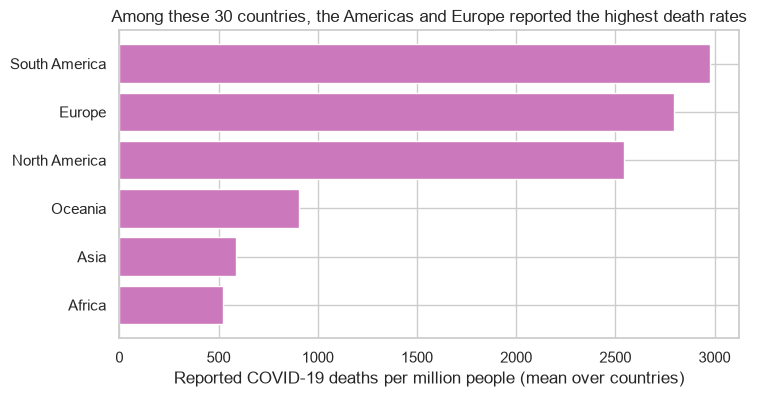

In [26]:
# The same table as a horizontal bar chart.
by_continent_sorted = by_continent.sort_values("deaths_per_million")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_continent_sorted.index,                      # continent names on the y-axis
        by_continent_sorted["deaths_per_million"],      # bar length = death rate
        color=palette[4], edgecolor="white")
ax.set_xlabel("Reported COVID-19 deaths per million people (mean over countries)")
ax.set_ylabel("")
ax.set_title("Among these 30 countries, the Americas and Europe reported the highest death rates")
plt.show()

South America, Europe, and North America reported roughly **5× the death rate** of Asia and Africa (among our 30 countries). Some of that gap is real — Africa's population is much younger, and age was the strongest risk factor — and some is measurement: countries with weaker death registration *counted* fewer COVID deaths. A wrangled table answers "what was reported"; deciding what was *true* is epidemiology.

## Recap

| Idea | Code |
|---|---|
| Filter to one level of data | `df[df["location_level"] == "national"].copy()` |
| Find / drop duplicate rows | `df.duplicated(subset=[...])`, `df.drop_duplicates(subset=[...])` |
| Drop a timezone | `df["date"].dt.tz_localize(None)` |
| Calendar math | `df["date"].dt.year`, `.dt.month`, `.dt.day_name()` |
| Filter by date | `df[df["date"] >= pd.Timestamp("2021-05-01")]` |
| Fraction missing per column | `df.isna().mean()` |
| Match a list of values | `df["country"].isin(["India", "Germany"])` |
| 7-day rolling average | `df["cases"].rolling(7).mean()` |
| Long → wide | `df.pivot(index="date", columns="country", values="cases")` |
| Wide → long | `wide.reset_index().melt(id_vars="date")` |
| Merge two tables on a key | `pd.merge(left, right, left_on=..., right_on=..., how="left")` |
| Post-merge safety check | `merged["new_col"].isna().sum()` |

Next: [exercises.md](exercises.md). The challenge at the end asks you to rebuild the per-million comparison for four countries of *your* choice.